In [6]:
"""
🎓 NOTEBOOK - DÉTECTION DE CHUTES AVEC DONNÉES RÉELLES MICRO:BIT
================================================================

Structure en cellules :
Chaque cellule a UN rôle bien défini et peut être exécutée indépendamment.
"""

# ============================================================
# EXÉCUTEZ LES CELLULES UNE PAR UNE DANS L'ORDRE !
# ============================================================

"""
==============================================================
CELLULE 1️ :  IMPORTS ET CONFIGURATION INITIALE
==============================================================

RÔLE : Importer toutes les bibliothèques nécessaires
       et configurer l'environnement
"""

# Installation des packages si nécessaire
import subprocess
import sys

packages = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'tensorflow', 'scipy']

print(" Vérification des packages...")
for package in packages:
    try:
        __import__(package)
        print(f" {package}")
    except ImportError:
        print(f" Installation de {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("\n Tous les packages sont prêts !\n")

# ============================================================
# Imports principaux
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from scipy import signal
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🎓 DÉTECTION DE CHUTES - NOTEBOOK STRUCTURÉ")
print("="*70)
print(f"\nTensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}\n")

 Vérification des packages...
 numpy
 pandas
 matplotlib
 seaborn
 Installation de scikit-learn...
 tensorflow
 scipy

 Tous les packages sont prêts !

🎓 DÉTECTION DE CHUTES - NOTEBOOK STRUCTURÉ

TensorFlow version: 2.20.0
Keras version: 3.13.2



In [2]:
"""
==============================================================
CELLULE 2️:  CHARGEMENT DES DONNÉES
==============================================================

RÔLE : Charger le fichier CSV du micro:bit
       et afficher les informations basiques

Résultat attendu :
- DataFrame avec colonnes : timestamp, acc_x, acc_y, acc_z, magnitude, label
- Voir la forme et le nombre de lignes
"""

print("\n" + "="*70)
print("CELLULE 2 : CHARGEMENT DES DONNÉES")
print("="*70)

# Charger le CSV
csv_path = '/content/dataset-microbit'
df = pd.read_csv(csv_path)

print(f"\n Données chargées !")
print(f"   - Fichier : dataset-microbit")
print(f"   - Nombre de lignes : {len(df)}")
print(f"   - Nombre de colonnes : {len(df.columns)}")
print(f"\n Colonnes :")
print(df.columns.tolist())

print(f"\n Dimensions :")
print(f"   Shape : {df.shape}")

print(f"\n Aperçu des données :")
print(df.head(10))

print(f"\n Types de données :")
print(df.dtypes)

print(f"\n Valeurs manquantes :")
print(df.isnull().sum())


CELLULE 2 : CHARGEMENT DES DONNÉES

📊 Données chargées !
   - Fichier : dataset-microbit
   - Nombre de lignes : 25450
   - Nombre de colonnes : 6

📋 Colonnes :
['timestamp', 'acc_x', 'acc_y', 'acc_z', 'magnitude', 'label']

📈 Dimensions :
   Shape : (25450, 6)

🔍 Aperçu des données :
                 timestamp  acc_x  acc_y  acc_z  magnitude    label
0  2026-06-03T14:01:16.060   -215    984    171    1021.63   marche
1  2026-06-03T14:04:55.640      0     -5    -15      15.81    chute
2  2026-06-03T14:01:05.740    459   1074   -116    1173.72   marche
3  2026-06-03T14:07:44.960      1    -27   1029    1029.35  allonge
4  2026-06-03T14:01:17.860    358   1095     13    1152.11   marche
5  2026-06-03T14:05:37.280    -47    893     62     896.38    chute
6  2026-06-03T14:07:18.820      5    -15   1005    1005.12  allonge
7  2026-06-03T14:01:57.020   -248   1090    -48    1118.89   marche
8  2026-06-03T14:00:02.040   -383   1174     21    1235.07   marche
9  2026-06-03T14:07:30.800     -9


CELLULE 3 : EXPLORATION ET STATISTIQUES

📊 Distribution des classes :
   marche       :   6400 ( 25.1%)
   chute        :   6350 ( 25.0%)
   allonge      :   6350 ( 25.0%)
   assis        :   6350 ( 25.0%)

📈 Statistiques descriptives de l'accélération :
              acc_x         acc_y        acc_z     magnitude
count  25450.000000  25450.000000  25450.00000  25450.000000
mean       1.017485    648.363026    247.83332    964.679719
std      236.315751    522.480079    479.11094    330.983545
min    -2038.000000  -2039.000000  -2045.00000      1.000000
25%      -23.000000     12.000000    -17.00000    977.430000
50%        0.000000    973.000000     17.00000   1001.520000
75%       23.000000   1018.000000    969.00000   1030.837500
max     2047.000000   2038.000000   2045.00000   3357.350000

📊 Plages de valeurs :
   acc_x  : [-2038.0,  2047.0] mG
   acc_y  : [-2039.0,  2038.0] mG
   acc_z  : [-2045.0,  2045.0] mG
   magnitude : [    1.0,  3357.3] mG


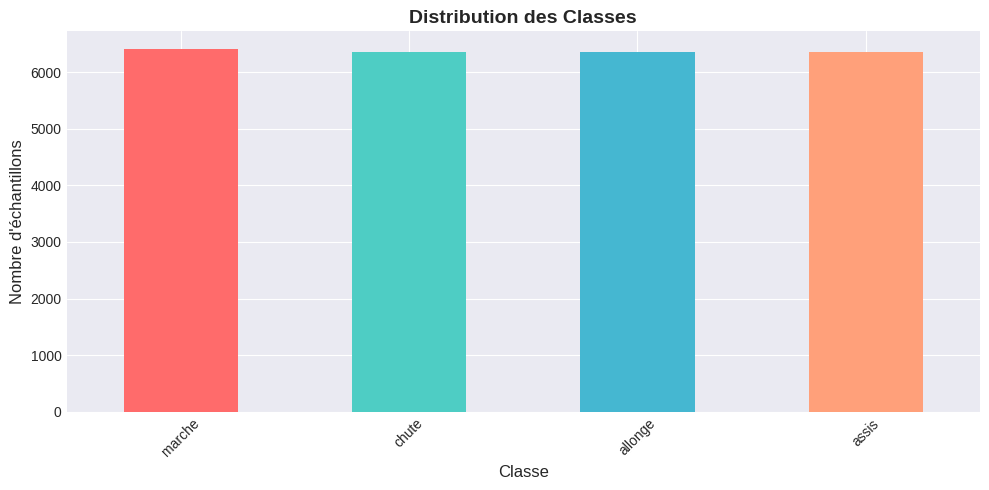

✅ Distribution des classes visualisée


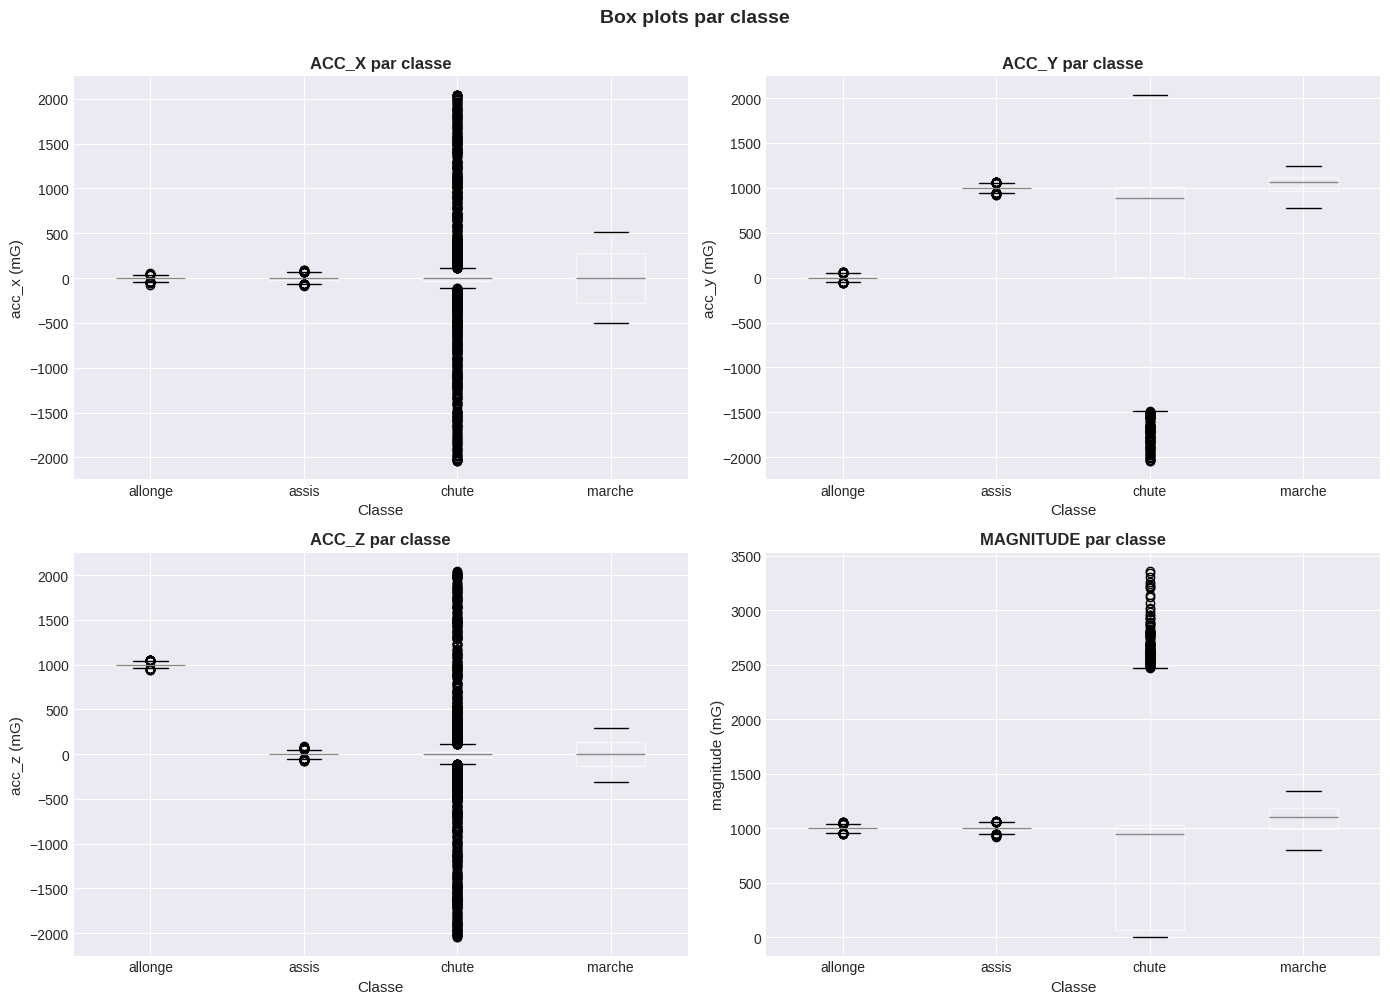

✅ Box plots visualisés


In [3]:
"""
==============================================================
CELLULE 3️ :  EXPLORATION ET STATISTIQUES
==============================================================

RÔLE : Analyser les données
       - Distribution des classes
       - Statistiques descriptives
       - Visualisations

Résultat attendu :
- Nombre d'échantillons par classe
- Plage des valeurs d'accélération
- Graphiques des distributions
"""

print("\n" + "="*70)
print("CELLULE 3 : EXPLORATION ET STATISTIQUES")
print("="*70)

# Distribution des classes
print(f"\n Distribution des classes :")
class_counts = df['label'].value_counts()
for label, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {label:12s} : {count:6d} ({percentage:5.1f}%)")

# Statistiques descriptives
print(f"\n📈 Statistiques descriptives de l'accélération :")
print(df[['acc_x', 'acc_y', 'acc_z', 'magnitude']].describe())

# Plages de valeurs
print(f"\n Plages de valeurs :")
print(f"   acc_x  : [{df['acc_x'].min():7.1f}, {df['acc_x'].max():7.1f}] mG")
print(f"   acc_y  : [{df['acc_y'].min():7.1f}, {df['acc_y'].max():7.1f}] mG")
print(f"   acc_z  : [{df['acc_z'].min():7.1f}, {df['acc_z'].max():7.1f}] mG")
print(f"   magnitude : [{df['magnitude'].min():7.1f}, {df['magnitude'].max():7.1f}] mG")

# Graphique : Distribution des classes
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
class_counts.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax.set_title('Distribution des Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Nombre d\'échantillons', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

print("Distribution des classes visualisée")

# Graphique : Box plot des accélérations par classe
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(['acc_x', 'acc_y', 'acc_z', 'magnitude']):
    ax = axes[idx // 2, idx % 2]
    df.boxplot(column=col, by='label', ax=ax)
    ax.set_title(f'{col.upper()} par classe', fontsize=12, fontweight='bold')
    ax.set_xlabel('Classe', fontsize=11)
    ax.set_ylabel(f'{col} (mG)', fontsize=11)

plt.suptitle('Box plots par classe', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(" Box plots visualisés")


CELLULE 4 : DATA CLEANING ET PRÉPARATION

 Conversion des accélérations (mG → g)...
   Conversion effectuée

 Suppression des outliers (Z-score > 3)...
  2450 outliers supprimés (9.63%)

 Application du filtre passe-bas (Butterworth)...
    Filtre passe-bas appliqué (cutoff=10Hz)

Normalisation des données (StandardScaler)...
    Données normalisées (mean≈0, std≈1)

 Statistiques après nettoyage :
   Lignes : 25450 → 23000 (90.4%)


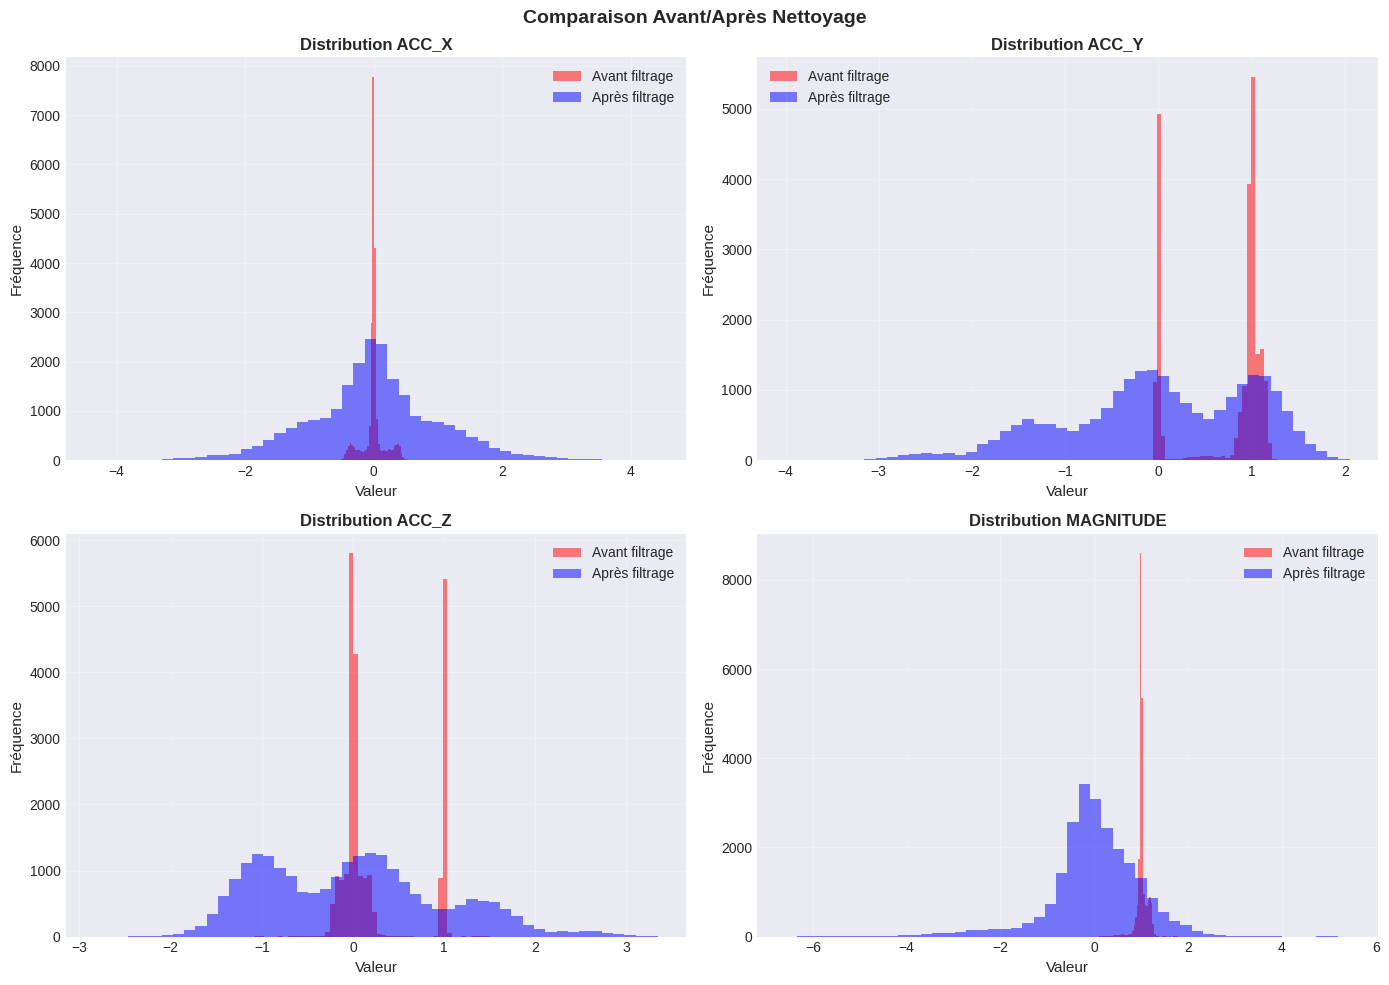

Graphiques de nettoyage affichés


In [8]:
"""
==============================================================
CELLULE 4️ :  DATA CLEANING ET PRÉPARATION
==============================================================

RÔLE : Nettoyer les données
       - Supprimer les outliers
       - Normaliser les valeurs
       - Appliquer un filtre passe-bas

Résultat attendu :
- Dataset propre et normalisé
- Pas de valeurs extrêmes
- Données prêtes pour le ML
"""

print("\n" + "="*70)
print("CELLULE 4 : DATA CLEANING ET PRÉPARATION")
print("="*70)

# Copier le dataframe
df_clean = df.copy()

# Convertir acc de mG à g
print("\n Conversion des accélérations (mG → g)...")
df_clean['acc_x'] = df_clean['acc_x'] / 1000.0
df_clean['acc_y'] = df_clean['acc_y'] / 1000.0
df_clean['acc_z'] = df_clean['acc_z'] / 1000.0
df_clean['magnitude'] = df_clean['magnitude'] / 1000.0
print(f"   Conversion effectuée")

# Supprimer les outliers (Z-score > 3)
print("\n Suppression des outliers (Z-score > 3)...")
initial_len = len(df_clean)

for col in ['acc_x', 'acc_y', 'acc_z', 'magnitude']:
    z_scores = np.abs((df_clean[col] - df_clean[col].mean()) / df_clean[col].std())
    df_clean = df_clean[z_scores < 3]

removed = initial_len - len(df_clean)
print(f"  {removed} outliers supprimés ({removed/initial_len*100:.2f}%)")

# Appliquer un filtre passe-bas (Butterworth)
print("\n Application du filtre passe-bas (Butterworth)...")
nyquist = 50 / 2  # Fréquence de Nyquist (50Hz sampling rate)
b, a = signal.butter(4, 10/nyquist, btype='low', analog=False)

df_filtered = df_clean.copy()
for col in ['acc_x', 'acc_y', 'acc_z', 'magnitude']:
    df_filtered[col] = signal.filtfilt(b, a, df_filtered[col])

print(f"    Filtre passe-bas appliqué (cutoff=10Hz)")

# Normaliser avec StandardScaler
print("\nNormalisation des données (StandardScaler)...")
scaler = StandardScaler()
cols_to_scale = ['acc_x', 'acc_y', 'acc_z', 'magnitude']
df_normalized = df_filtered.copy()
df_normalized[cols_to_scale] = scaler.fit_transform(df_filtered[cols_to_scale])

print(f"    Données normalisées (mean≈0, std≈1)")

print(f"\n Statistiques après nettoyage :")
print(f"   Lignes : {initial_len} → {len(df_normalized)} ({100*len(df_normalized)/initial_len:.1f}%)")

# Visualiser avant/après
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(['acc_x', 'acc_y', 'acc_z', 'magnitude']):
    ax = axes[idx // 2, idx % 2]

    # Avant
    ax.hist(df_clean[col], bins=50, alpha=0.5, label='Avant filtrage', color='red')
    # Après
    ax.hist(df_normalized[col], bins=50, alpha=0.5, label='Après filtrage', color='blue')

    ax.set_title(f'Distribution {col.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valeur', fontsize=11)
    ax.set_ylabel('Fréquence', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison Avant/Après Nettoyage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Graphiques de nettoyage affichés")

In [9]:
"""
==============================================================
CELLULE 5️ :  CRÉATION DES FENÊTRES GLISSANTES
==============================================================

RÔLE : Créer des fenêtres de 100 timesteps
       avec un overlap de 50%

Format final : (nombre_fenêtres, 100, 4)
              - 100 timesteps
              - 4 features (X, Y, Z, magnitude)

Résultat attendu :
- X_windows shape : (N, 100, 4)
- y_labels shape : (N,)
- Fenêtres prêtes pour LSTM
"""

from collections import defaultdict
import numpy as np
import pandas as pd

print("\n" + "="*70)
print("CELLULE 5 : CRÉATION DES FENÊTRES (PAR SEGMENTS)")
print("="*70)


print("Tri chronologique des données en cours...")
df_normalized['timestamp'] = pd.to_datetime(df_normalized['timestamp'])
df_normalized = df_normalized.sort_values('timestamp').reset_index(drop=True)
print("Données remises dans le bon ordre !\n")

# 1. PARAMÈTRES
window_size = 100  # 100 timesteps = 2 secondes (à 50Hz)
step_size = 50     # 50 timesteps d'avancement = 1 seconde d'overlap

print(f"Étape 1 : Création des segments (détection des changements d'activité)...")

# 2. CRÉATION DES SEGMENTS (Regrouper les données consécutives du même label)
segments = []
current_label = df_normalized['label'].iloc[0]
start_idx = 0

for i in range(1, len(df_normalized)):
    if df_normalized['label'].iloc[i] != current_label:
        segments.append({
            'label': current_label,
            'start': start_idx,
            'end': i,
            'size': i - start_idx
        })
        current_label = df_normalized['label'].iloc[i]
        start_idx = i

# Ajouter le dernier segment
segments.append({
    'label': current_label,
    'start': start_idx,
    'end': len(df_normalized),
    'size': len(df_normalized) - start_idx
})

print(f"{len(segments)} segments d'activités consécutives détectés.")

# 3. CRÉATION DES FENÊTRES
print(f"\n Étape 2 : Création des fenêtres (window_size={window_size}, step_size={step_size})...\n")

windows = []
labels = []
windows_per_segment = defaultdict(int)

for seg_idx, seg in enumerate(segments):
    label = seg['label']
    start = seg['start']
    end = seg['end']
    size = seg['size']

    # Extraire les données du segment
    segment_data = df_normalized.iloc[start:end][['acc_x', 'acc_y', 'acc_z', 'magnitude']].values

    # Créer les fenêtres glissantes si le segment est assez grand
    if size >= window_size:
        windows_created = 0
        for start_idx_window in range(0, size - window_size + 1, step_size):
            window = segment_data[start_idx_window:start_idx_window + window_size]
            windows.append(window)
            labels.append(label)
            windows_created += 1

        windows_per_segment[label] += windows_created

        # Afficher info pour chaque segment avec des données
        if seg_idx < 20:
            print(f"   Segment {seg_idx:2d}: '{label:10s}' ({size:4d} points) → {windows_created:2d} fenêtres ")
    else:
        if seg_idx < 20:
            print(f"   Segment {seg_idx:2d}: '{label:10s}' ({size:4d} points) → SKIPPED (trop court) ")

if len(segments) > 20:
    print(f"   ... ({len(segments) - 20} segments restants masqués pour la lisibilité)\n")

# 4. CONVERSION EN TENSEURS NUMPY POUR LE RÉSEAU DE NEURONES
X_windows = np.array(windows)
y_labels = np.array(labels)

print(f"\n RÉSULTAT FINAL : {len(windows)} fenêtres créées !")
print(f"Forme de X_windows : {X_windows.shape}")
print(f" Forme de y_labels  : {y_labels.shape}")

if len(windows) > 0:
    print("\n C'est parfait ! Tu peux maintenant lancer la Cellule 6 (Encodage des labels).")
else:
    print("\n Aïe, toujours 0 fenêtre. Essaie de réduire 'window_size' à 50.")


CELLULE 5 : CRÉATION DES FENÊTRES (PAR SEGMENTS)
Tri chronologique des données en cours...
Données remises dans le bon ordre !

Étape 1 : Création des segments (détection des changements d'activité)...
4 segments d'activités consécutives détectés.

 Étape 2 : Création des fenêtres (window_size=100, step_size=50)...

   Segment  0: 'marche    ' (6400 points) → 127 fenêtres 
   Segment  1: 'assis     ' (6350 points) → 126 fenêtres 
   Segment  2: 'chute     ' (3900 points) → 77 fenêtres 
   Segment  3: 'allonge   ' (6350 points) → 126 fenêtres 

 RÉSULTAT FINAL : 456 fenêtres créées !
Forme de X_windows : (456, 100, 4)
 Forme de y_labels  : (456,)

 C'est parfait ! Tu peux maintenant lancer la Cellule 6 (Encodage des labels).


In [10]:
"""
==============================================================
CELLULE 6️ :  ENCODAGE DES LABELS
==============================================================

RÔLE : Convertir les labels texte en nombres
       Créer le one-hot encoding pour le réseau

Résultat attendu :
- y_encoded : labels en nombres
- y_categorical : one-hot encoding
- Dictionnaire classe → nombre
"""

print("\n" + "="*70)
print("CELLULE 6 : ENCODAGE DES LABELS")
print("="*70)

# LabelEncoder
print("\n Encodage des labels...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print(f"    Labels encodés")

# Afficher la table de conversion
print(f"\n Table de conversion :")
for i, class_name in enumerate(label_encoder.classes_):
    count = np.sum(y_labels == class_name)
    print(f"   {class_name:12s} → {i}  ({count} fenêtres)")

# One-hot encoding
print(f"\n Création du one-hot encoding...")
y_categorical = to_categorical(y_encoded)
print(f"   One-hot encoding créé")

print(f"\n Forme après one-hot :")
print(f"   - y_categorical shape : {y_categorical.shape}")
print(f"\n Exemple :")
print(f"   Classe : {y_labels[0]}")
print(f"   Encoded : {y_encoded[0]}")
print(f"   One-hot : {y_categorical[0]}")

# Sauvegarder l'encodeur
with open('label_encoder_classes.json', 'w') as f:
    json.dump(list(label_encoder.classes_), f)
print(f"\n Encodeur sauvegardé")


CELLULE 6 : ENCODAGE DES LABELS

 Encodage des labels...
    Labels encodés

 Table de conversion :
   allonge      → 0  (126 fenêtres)
   assis        → 1  (126 fenêtres)
   chute        → 2  (77 fenêtres)
   marche       → 3  (127 fenêtres)

 Création du one-hot encoding...
   One-hot encoding créé

 Forme après one-hot :
   - y_categorical shape : (456, 4)

 Exemple :
   Classe : marche
   Encoded : 3
   One-hot : [0. 0. 0. 1.]

 Encodeur sauvegardé


In [11]:
"""
==============================================================
CELLULE 7️ :  SÉPARATION TRAIN/TEST
==============================================================

RÔLE : Diviser les données en :
       - 80% pour l'entraînement
       - 20% pour les tests

Résultat attendu :
- X_train, X_test
- y_train, y_test
- Distributions préservées dans train ET test
"""

print("\n" + "="*70)
print("CELLULE 7 : SÉPARATION TRAIN/TEST")
print("="*70)

print(f"\n Séparation train/test (80/20)...")

X_train, X_test, y_train, y_test = train_test_split(
    X_windows,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Préserve la distribution
)

print(f"    Séparation effectuée")

print(f"\n Tailles des ensembles :")
print(f"   - X_train : {X_train.shape} ({len(X_train)/len(X_windows)*100:.0f}%)")
print(f"   - X_test  : {X_test.shape} ({len(X_test)/len(X_windows)*100:.0f}%)")
print(f"   - y_train : {y_train.shape}")
print(f"   - y_test  : {y_test.shape}")

print(f"\n Distribution dans train :")
y_train_classes = np.argmax(y_train, axis=1)
for i, class_name in enumerate(label_encoder.classes_):
    count = np.sum(y_train_classes == i)
    print(f"   {class_name:12s} : {count:4d} ({count/len(y_train)*100:5.1f}%)")

print(f"\n Distribution dans test :")
y_test_classes = np.argmax(y_test, axis=1)
for i, class_name in enumerate(label_encoder.classes_):
    count = np.sum(y_test_classes == i)
    print(f"   {class_name:12s} : {count:4d} ({count/len(y_test)*100:5.1f}%)")


CELLULE 7 : SÉPARATION TRAIN/TEST

 Séparation train/test (80/20)...
    Séparation effectuée

 Tailles des ensembles :
   - X_train : (364, 100, 4) (80%)
   - X_test  : (92, 100, 4) (20%)
   - y_train : (364, 4)
   - y_test  : (92, 4)

 Distribution dans train :
   allonge      :  101 ( 27.7%)
   assis        :  101 ( 27.7%)
   chute        :   61 ( 16.8%)
   marche       :  101 ( 27.7%)

 Distribution dans test :
   allonge      :   25 ( 27.2%)
   assis        :   25 ( 27.2%)
   chute        :   16 ( 17.4%)
   marche       :   26 ( 28.3%)


In [13]:
"""
==============================================================
CELLULE 8️ :  CONSTRUCTION DE L'ARCHITECTURE LSTM
==============================================================

RÔLE : Créer l'architecture du réseau de neurones
       - 2 couches LSTM
       - 2 couches Dropout
       - 2 couches Dense
       - Total : ~30k paramètres

Résultat attendu :
- Modèle compilé et prêt
- Architecture affichée
"""

print("\n" + "="*70)
print("CELLULE 8 : CONSTRUCTION DE L'ARCHITECTURE LSTM")
print("="*70)

# Paramètres du réseau
n_timesteps = X_train.shape[1]  # 100
n_features = X_train.shape[2]    # 4
n_classes = y_train.shape[1]     # 4

print(f"\n Paramètres du réseau :")
print(f"   - Input shape : ({n_timesteps}, {n_features})")
print(f"   - Nombre de classes : {n_classes}")

# Créer le modèle
print(f"\n Construction du modèle...")

model = Sequential([
    # Couche LSTM 1
    LSTM(
        128,
        return_sequences=True,
        input_shape=(n_timesteps, n_features),
        name='lstm_1'
    ),
    Dropout(0.3, name='dropout_1'),

    # Couche LSTM 2
    LSTM(64, return_sequences=False, name='lstm_2'),
    Dropout(0.3, name='dropout_2'),

    # Couche Dense intermédiaire
    Dense(32, activation='relu', name='dense_1'),
    Dropout(0.2, name='dropout_3'),

    # Couche de sortie
    Dense(n_classes, activation='softmax', name='output')
], name='fall_detection_model')

print(f"    Modèle créé")

# Compiler
print(f"\n Compilation du modèle...")
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"  Modèle compilé")

# Afficher le résumé
print(f"\n Architecture du réseau :")
model.summary()


CELLULE 8 : CONSTRUCTION DE L'ARCHITECTURE LSTM

 Paramètres du réseau :
   - Input shape : (100, 4)
   - Nombre de classes : 4

 Construction du modèle...
    Modèle créé

 Compilation du modèle...
  Modèle compilé

 Architecture du réseau :


Model: "fall_detection_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100, 128)       │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,716 (467.64 KB)

 Trainable params: 119,716 (467.64 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
"""
==============================================================
CELLULE 9️ :  ENTRAÎNEMENT DU MODÈLE
==============================================================

RÔLE : Entraîner le modèle LSTM
       - Jusqu'à 100 epochs
       - Avec Early Stopping (patience=15)
       - Avec ReduceLROnPlateau
       - Avec ModelCheckpoint

Résultat attendu :
- Modèle entraîné
- Meilleur modèle sauvegardé
- Courbes d'apprentissage
"""

print("\n" + "="*70)
print("CELLULE 9 : ENTRAÎNEMENT DU MODÈLE")
print("="*70)

print(f"\n Configuration des callbacks...")

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

# ModelCheckpoint
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

print(f"    Callbacks configurés")

print(f"\n Paramètres d'entraînement :")
print(f"   - Epochs : jusqu'à 100")
print(f"   - Batch size : 32")
print(f"   - Validation split : 20%")
print(f"   - Early Stopping : patience=15")

print(f"\n" + "="*70)
print(f" DÉBUT DE L'ENTRAÎNEMENT...")
print(f"="*70 + "\n")

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print(f"\n" + "="*70)
print(f" ENTRAÎNEMENT TERMINÉ !")
print(f"="*70)

# Statistiques d'entraînement
print(f"\n Statistiques d'entraînement :")
print(f"   - Epochs effectués : {len(history.history['loss'])}")
print(f"   - Loss finale : {history.history['loss'][-1]:.4f}")
print(f"   - Accuracy finale : {history.history['accuracy'][-1]*100:.2f}%")
print(f"   - Val Loss finale : {history.history['val_loss'][-1]:.4f}")
print(f"   - Val Accuracy finale : {history.history['val_accuracy'][-1]*100:.2f}%")


CELLULE 9 : ENTRAÎNEMENT DU MODÈLE

 Configuration des callbacks...
    Callbacks configurés

 Paramètres d'entraînement :
   - Epochs : jusqu'à 100
   - Batch size : 32
   - Validation split : 20%
   - Early Stopping : patience=15

 DÉBUT DE L'ENTRAÎNEMENT...

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.5067 - loss: 1.2414

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 412ms/step - accuracy: 0.5739 - loss: 1.1271 - val_accuracy: 0.5616 - val_loss: 0.8461 - learning_rate: 0.0010
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6481 - loss: 0.8223

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 420ms/step - accuracy: 0.6804 - loss: 0.8036 - val_accuracy: 0.7808 - val_loss: 0.6419 - learning_rate: 0.0010
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.8110 - loss: 0.5883 - val_accuracy: 0.7808 - val_loss: 0.4448 - learning_rate: 0.0010
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 367ms/step - accuracy: 0.8454 - loss: 0.4033 - val_accuracy: 0.7671 - val_loss: 0.4303 - learning_rate: 0.0010
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 367ms/step - accuracy: 0.8488 - loss: 0.3836 - val_accuracy: 0.7808 - val_loss: 0.4176 - learning_rate: 0.0010
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 330ms/step - accuracy: 0.8144 - loss: 0.4060 - val_accuracy: 0.7808 - val_loss: 0.4021 - learning_rate: 0.0010
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - accuracy: 0.8488 - loss: 0.3461 - val_accuracy: 0.7808 - val_loss: 0.3686 - learning_rate: 0.0010
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - accuracy: 0.8419 - loss: 0.3308 - val_a

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - accuracy: 0.8316 - loss: 0.3158 - val_accuracy: 0.7945 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.8625 - loss: 0.2791 - val_accuracy: 0.7945 - val_loss: 0.3644 - learning_rate: 0.0010
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 381ms/step - accuracy: 0.8557 - loss: 0.2889 - val_accuracy: 0.7945 - val_loss: 0.3444 - learning_rate: 0.0010
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 0.8625 - loss: 0.2841 - val_accuracy: 0.7945 - val_loss: 0.3931 - learning_rate: 0.0010
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 0.8763 - loss: 0.2726 - val_accuracy: 0.7945 - val_loss: 0.3331 - learning_rate: 0.0010
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - accuracy: 0.8591 - loss: 0.2765 - val_accuracy: 0.7945 - val_loss: 0.3698 - learning_rate: 0.0010
Epoch 16/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8562 - loss: 0.2735

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 409ms/step - accuracy: 0.8454 - loss: 0.2922 - val_accuracy: 0.8082 - val_loss: 0.3507 - learning_rate: 0.0010
Epoch 17/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - accuracy: 0.8522 - loss: 0.2789 - val_accuracy: 0.7945 - val_loss: 0.3843 - learning_rate: 0.0010
Epoch 18/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 275ms/step - accuracy: 0.8694 - loss: 0.2877 - val_accuracy: 0.7945 - val_loss: 0.3922 - learning_rate: 0.0010
Epoch 19/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.8729 - loss: 0.2920 - val_accuracy: 0.7945 - val_loss: 0.3492 - learning_rate: 0.0010
Epoch 20/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 304ms/step - accuracy: 0.8729 - loss: 0.2752 - val_accuracy: 0.7945 - val_loss: 0.3430 - learning_rate: 0.0010
Epoch 21/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8356 - loss: 0.2801
Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.8557 - loss: 0.2705 - v

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.8866 - loss: 0.2368 - val_accuracy: 0.8219 - val_loss: 0.3286 - learning_rate: 5.0000e-04
Epoch 30/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8606 - loss: 0.2737
Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.8729 - loss: 0.2515 - val_accuracy: 0.8082 - val_loss: 0.3500 - learning_rate: 5.0000e-04
Epoch 31/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.8900 - loss: 0.2502 - val_accuracy: 0.7945 - val_loss: 0.3736 - learning_rate: 2.5000e-04
Epoch 32/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - accuracy: 0.8969 - loss: 0.2396 - val_accuracy: 0.7945 - val_loss: 0.3806 - learning_rate: 2.5000e-04
Epoch 33/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.8935 - loss: 0.2462 - val_accuracy: 0.7945 - val_loss: 0.3784 - learning_rate: 2.5000e-04
Epoch 34/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.886


CELLULE 10 : VISUALISATION DES COURBES D'APPRENTISSAGE


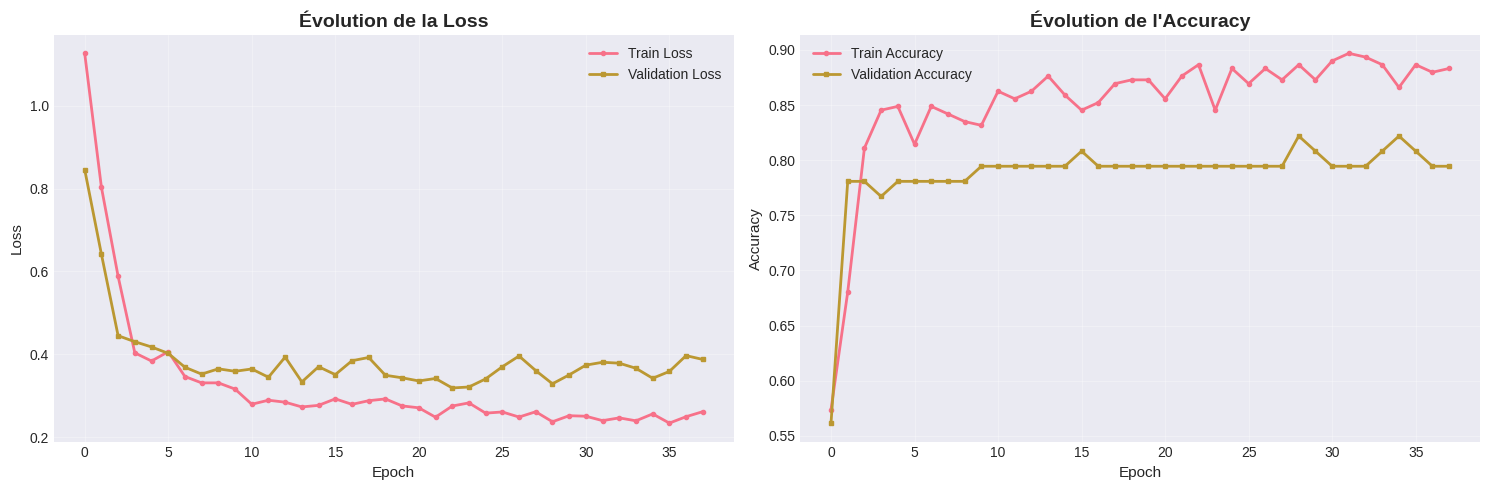

Courbes d'apprentissage affichées


In [15]:
"""
==============================================================
CELLULE 10:  VISUALISATION DES COURBES D'APPRENTISSAGE
==============================================================

RÔLE : Afficher les courbes de loss et accuracy
       pendant l'entraînement

Résultat attendu :
- Graphiques de loss (train vs validation)
- Graphiques d'accuracy (train vs validation)
- Pas de surapprentissage évident
"""

print("\n" + "="*70)
print("CELLULE 10 : VISUALISATION DES COURBES D'APPRENTISSAGE")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=3)
axes[0].set_title('Évolution de la Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o', markersize=3)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s', markersize=3)
axes[1].set_title('Évolution de l\'Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Courbes d'apprentissage affichées")

In [16]:
"""
==============================================================
CELLULE 1️1 : CHARGEMENT DU MEILLEUR MODÈLE
==============================================================

RÔLE : Charger le meilleur modèle sauvegardé
       (celui avec la meilleure validation accuracy)

Résultat attendu :
- Meilleur modèle chargé
- Prêt pour l'évaluation
"""

print("\n" + "="*70)
print("CELLULE 11 : CHARGEMENT DU MEILLEUR MODÈLE")
print("="*70)

print(f"\n Chargement du meilleur modèle...")
try:
    model = keras.models.load_model('best_model.h5')
    print(f"  Meilleur modèle chargé depuis best_model.h5")
except:
    print(f"   Utilisation du modèle final (best_model.h5 non trouvé)")


CELLULE 11 : CHARGEMENT DU MEILLEUR MODÈLE

 Chargement du meilleur modèle...


  Meilleur modèle chargé depuis best_model.h5



CELLULE 12 : ÉVALUATION SUR LES DONNÉES DE TEST

 Évaluation du modèle...

🎯 RÉSULTATS SUR LES DONNÉES DE TEST :
   - Test Loss : 0.3146
   - Test Accuracy : 83.70%

RAPPORT DE CLASSIFICATION DÉTAILLÉ

              precision    recall  f1-score   support

     allonge      1.000     1.000     1.000        25
       assis      0.679     0.760     0.717        25
       chute      0.538     0.438     0.483        16
      marche      1.000     1.000     1.000        26

    accuracy                          0.837        92
   macro avg      0.804     0.799     0.800        92
weighted avg      0.832     0.837     0.833        92


📊 Matrice de confusion :
[[25  0  0  0]
 [ 0 19  6  0]
 [ 0  9  7  0]
 [ 0  0  0 26]]


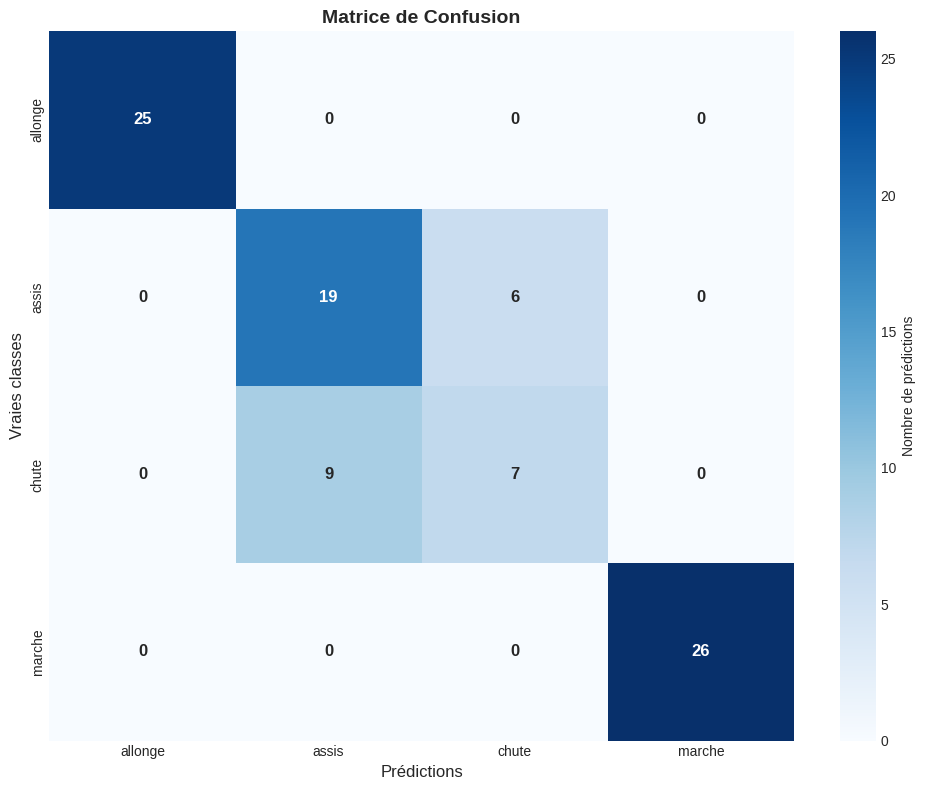

✅ Matrice de confusion visualisée


In [17]:
"""
==============================================================
CELLULE 1️2️ : ÉVALUATION SUR LES DONNÉES DE TEST
==============================================================

RÔLE : Évaluer le modèle sur les données de test
       - Calcul du loss et accuracy
       - Rapport de classification
       - Matrice de confusion

Résultat attendu :
- Accuracy test
- Précision par classe
- F1-score
"""

print("\n" + "="*70)
print("CELLULE 12 : ÉVALUATION SUR LES DONNÉES DE TEST")
print("="*70)

print(f"\n Évaluation du modèle...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\n RÉSULTATS SUR LES DONNÉES DE TEST :")
print(f"   - Test Loss : {test_loss:.4f}")
print(f"   - Test Accuracy : {test_accuracy*100:.2f}%")

# Prédictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Rapport de classification
print(f"\n" + "="*70)
print(f"RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print(f"="*70)
print()
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=label_encoder.classes_,
    digits=3
))

# Matrice de confusion
cm = confusion_matrix(y_test_classes, y_pred_classes)

print(f"\n Matrice de confusion :")
print(cm)

# Visualiser matrice
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Nombre de prédictions'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Matrice de Confusion', fontsize=14, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vraies classes', fontsize=12)
plt.tight_layout()
plt.show()

print("Matrice de confusion visualisée")

In [21]:
"""
==============================================================
CELLULE 1️3️ :  SAUVEGARDE DU MODÈLE (H5, Keras et TensorFlow)
==============================================================
"""

print("\n" + "="*70)
print("CELLULE 13 : SAUVEGARDE DU MODÈLE")
print("="*70)

# 1. Sauvegarder aux formats standards (H5 et le nouveau .keras)
print(f"\n Sauvegarde en formats Keras et H5...")
model.save('modele_chute.keras')  # Nouveau format standard (sans warning)
model.save('modele_chute.h5')     # Ancien format (gardé par sécurité pour la suite)
print(f"    modele_chute.keras et modele_chute.h5 sauvegardés")

# 2. Sauvegarder en format SavedModel (Correction Keras 3)
print(f"\n Sauvegarde en format SavedModel...")
try:
    # Nouvelle méthode Keras 3
    model.export('modele_chute_tf')
except AttributeError:
    # Ancienne méthode (au cas où Colab rétrograde sa version)
    model.save('modele_chute_tf', save_format='tf')
print(f"    modele_chute_tf/ sauvegardé")

# 3. Sauvegarder l'encodeur et le scaler
print(f"\n Sauvegarde de l'encodeur et du scaler...")
import pickle
import json

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"   label_encoder.pkl sauvegardé")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"    scaler.pkl sauvegardé")

# 4. Sauvegarde les paramètres de normalisation (pour M5Stack)
normalization_params = {
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'classes': label_encoder.classes_.tolist(),
    'sampling_rate': 50,
    'window_size': 100
}

with open('normalization_params.json', 'w') as f:
    json.dump(normalization_params, f, indent=2)
print(f"    normalization_params.json sauvegardé")

print(f"\n TOUS LES MODÈLES ET PARAMÈTRES SONT SAUVEGARDÉS !")


CELLULE 13 : SAUVEGARDE DU MODÈLE

 Sauvegarde en formats Keras et H5...
    modele_chute.keras et modele_chute.h5 sauvegardés

 Sauvegarde en format SavedModel...
Saved artifact at 'modele_chute_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 4), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140184147946640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147944912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147946832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147948176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147936848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147943760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147943952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147944144: TensorSpec(shape=(), dtype=tf.resource, name=No

In [22]:
"""
==============================================================
CELLULE 1️4️ :  EXPORT DES POIDS EN CSV (POUR M5STACK)
==============================================================

RÔLE : Exporter les poids du réseau en format CSV
       Pour utilisation directe sur M5Stack Tab5

Format CSV :
- Une ligne par paramètre/poids
- Colonnes : layer_name, index, value

Résultat attendu :
- Fichier CSV avec tous les poids
- Prêt pour M5Stack
"""

print("\n" + "="*70)
print("CELLULE 14 : EXPORT DES POIDS EN CSV")
print("="*70)

print(f"\n Extraction des poids du modèle...")

# Récupérer les poids
weights_data = []

for i, layer in enumerate(model.layers):
    layer_name = layer.name
    layer_weights = layer.get_weights()

    if len(layer_weights) > 0:
        print(f"   Couche {i}: {layer_name}")

        for weight_idx, weight_matrix in enumerate(layer_weights):
            # Aplatir la matrice en 1D
            flat_weights = weight_matrix.flatten()

            for param_idx, value in enumerate(flat_weights):
                weights_data.append({
                    'layer_index': i,
                    'layer_name': layer_name,
                    'weight_matrix_index': weight_idx,
                    'parameter_index': param_idx,
                    'value': float(value)
                })

            print(f"      └─ Matrice {weight_idx}: shape {weight_matrix.shape} → {len(flat_weights)} paramètres")

# Créer DataFrame
df_weights = pd.DataFrame(weights_data)

print(f"\n {len(df_weights)} poids extraits")

print(f"\n Structure du fichier CSV :")
print(df_weights.head(10))

print(f"\n Sauvegarde du CSV...")
df_weights.to_csv('modele_poids.csv', index=False)
print(f"    modele_poids.csv sauvegardé ({len(df_weights)} lignes)")

# Créer aussi une version simplifiée (juste les valeurs)
df_weights_simple = df_weights[['layer_name', 'parameter_index', 'value']]
df_weights_simple.to_csv('modele_poids_simple.csv', index=False)
print(f"    modele_poids_simple.csv sauvegardé (version simplifiée)")

print(f"\n Statistiques des poids :")
print(f"   - Min : {df_weights['value'].min():.6f}")
print(f"   - Max : {df_weights['value'].max():.6f}")
print(f"   - Moyenne : {df_weights['value'].mean():.6f}")
print(f"   - Écart-type : {df_weights['value'].std():.6f}")


CELLULE 14 : EXPORT DES POIDS EN CSV

 Extraction des poids du modèle...
   Couche 0: lstm_1
      └─ Matrice 0: shape (4, 512) → 2048 paramètres
      └─ Matrice 1: shape (128, 512) → 65536 paramètres
      └─ Matrice 2: shape (512,) → 512 paramètres
   Couche 2: lstm_2
      └─ Matrice 0: shape (128, 256) → 32768 paramètres
      └─ Matrice 1: shape (64, 256) → 16384 paramètres
      └─ Matrice 2: shape (256,) → 256 paramètres
   Couche 4: dense_1
      └─ Matrice 0: shape (64, 32) → 2048 paramètres
      └─ Matrice 1: shape (32,) → 32 paramètres
   Couche 6: output
      └─ Matrice 0: shape (32, 4) → 128 paramètres
      └─ Matrice 1: shape (4,) → 4 paramètres

 119716 poids extraits

 Structure du fichier CSV :
   layer_index layer_name  weight_matrix_index  parameter_index     value
0            0     lstm_1                    0                0  0.110365
1            0     lstm_1                    0                1 -0.058351
2            0     lstm_1                    0      

In [27]:
"""
==============================================================
CELLULE 1️5 :  CONVERSION EN TENSORFLOW LITE (TinyML)
==============================================================
"""
import tensorflow as tf
import os

print("\n" + "="*70)
print("CELLULE 16 : CONVERSION TFLITE POUR M5STACK")
print("="*70)

# 1. Convertir le modèle en TFLite
print("\n Conversion du modèle en TensorFlow Lite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimisation pour réduire la taille (très important pour M5Stack)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, # Opérations standard TFLite
    tf.lite.OpsSet.SELECT_TF_OPS    # Nécessaire pour certains modèles LSTM
]

tflite_model = converter.convert()

# 2. Sauvegarder le fichier binaire .tflite (si tu veux utiliser la carte SD)
with open('modele_chute.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"    Fichier modele_chute.tflite généré ! ({len(tflite_model)/1024:.1f} KB)")

# 3. Convertir en tableau C++ (Recommandé : Pas besoin de carte SD)
print("\n Génération du fichier C++ (Header)...")
def hex_to_c_array(hex_data, var_name):
    c_str = f"// Fichier généré automatiquement pour M5Stack\n"
    c_str += f"#include <Arduino.h>\n\n"
    c_str += f"const unsigned char {var_name}[] PROGMEM = {{\n"
    hex_array = [hex(b) for b in hex_data]
    for i in range(0, len(hex_array), 12):
        c_str += "  " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_str += "};\n"
    c_str += f"const unsigned int {var_name}_len = {len(hex_data)};\n"
    return c_str

with open('modele_chute.h', 'w') as f:
    f.write(hex_to_c_array(tflite_model, "modele_chute_tflite"))

print(f"    Fichier modele_chute.h généré !")
print("\n TELECHARGE LE FICHIER 'modele_chute.h' A GAUCHE DANS COLAB !")


CELLULE 16 : CONVERSION TFLITE POUR M5STACK

 Conversion du modèle en TensorFlow Lite...
Saved artifact at '/tmp/tmpjxt5z8ih'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 4), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140184147946640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147944912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147946832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147948176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147936848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147943760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147943952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147944144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140184147947408: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [29]:
# Générateur de code C++ pour les paramètres
print("\n//  COPIE-COLLE CE BLOC DIRECTEMENT DANS TON CODE ARDUINO ")
print(f"const float scaler_mean[4] = {{{', '.join([f'{x:.6f}' for x in scaler.mean_])}}};")
print(f"const float scaler_scale[4] = {{{', '.join([f'{x:.6f}' for x in scaler.scale_])}}};")

classes_str = ', '.join([f'"{c}"' for c in label_encoder.classes_])
print(f"const String classes[4] = {{{classes_str}}};")
print("//  ---------------------------------------------------- \n")

print(f" recuper le bloc arduino et le coller dans ton code arduinon")


//  COPIE-COLLE CE BLOC DIRECTEMENT DANS TON CODE ARDUINO 
const float scaler_mean[4] = {-0.000361, 0.718680, 0.276890, 1.012660};
const float scaler_scale[4] = {0.095331, 0.279200, 0.277345, 0.070183};
const String classes[4] = {"allonge", "assis", "chute", "marche"};
//  ---------------------------------------------------- 

 recuper le bloc arduino et le coller dans ton code arduinon
